In [1]:
# =========================
# CELL 0 — (Colab) Mount Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted.")


Mounted at /content/drive
Google Drive mounted.


In [2]:
# =========================
# CELL 1 — Config
# =========================
import os, glob
import numpy as np

# Folder containing per-video features (.npy), each file is typically shape [T, D]
INPUT_FEATURES_PATH = "/content/drive/My Drive/egovlp/features/egovlp"

# Output folder
OUTPUT_PATH = "/content/drive/My Drive/AML_Project/step_level_features"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# IMPORTANT: seconds between consecutive feature vectors
# Example: if you extracted 1 feature every 2 seconds, set STRIDE_SEC=2.0
STRIDE_SEC = 2.0   # <-- CHANGE THIS TO YOUR REAL STRIDE

print("INPUT_FEATURES_PATH:", INPUT_FEATURES_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("STRIDE_SEC:", STRIDE_SEC)


INPUT_FEATURES_PATH: /content/drive/My Drive/egovlp/features/egovlp
OUTPUT_PATH: /content/drive/My Drive/AML_Project/step_level_features
STRIDE_SEC: 2.0


In [3]:
# =========================
# CELL 2 — Step localization + step embeddings
# =========================
import numpy as np
from sklearn.cluster import KMeans

def _l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(n, eps)

def _segments_from_labels(labels: np.ndarray):
    """Convert frame/clip labels into contiguous segments in index space: [(start_idx, end_idx), ...], end exclusive."""
    T = len(labels)
    if T == 0:
        return []
    segments = []
    start = 0
    for i in range(1, T):
        if labels[i] != labels[i - 1]:
            segments.append((start, i))
            start = i
    segments.append((start, T))
    return segments

def _merge_short_segments(segments, min_len: int):
    """
    Merge segments shorter than min_len with a neighbor.
    Simple and robust post-processing.
    """
    if not segments:
        return []
    segs = segments[:]
    changed = True
    while changed and len(segs) > 1:
        changed = False
        new_segs = []
        i = 0
        while i < len(segs):
            s, e = segs[i]
            if (e - s) >= min_len:
                new_segs.append((s, e))
                i += 1
                continue

            # segment too short -> merge with best neighbor (prefer previous if exists, else next)
            changed = True
            if len(new_segs) > 0:
                ps, pe = new_segs.pop()
                new_segs.append((ps, e))  # merge into previous
                i += 1
            else:
                # no previous, merge into next
                ns, ne = segs[i + 1]
                new_segs.append((s, ne))
                i += 2

        segs = new_segs
    return segs

def localize_steps_clustering(
    features: np.ndarray,
    stride_sec: float,
    n_clusters: int | None = None,
    min_step_len: int = 3,
    random_state: int = 42
):
    """
    Zero-shot clustering baseline for step localization.
    Input:  features [T, D]
    Output: segments_sec  [N, 2]  (start_sec, end_sec)
            segments_idx  [N, 2]  (start_idx, end_idx)
    """
    if features.ndim != 2:
        raise ValueError(f"Expected features [T, D], got shape {features.shape}")

    T, D = features.shape
    if T == 0:
        return np.zeros((0, 2), dtype=np.float32), np.zeros((0, 2), dtype=np.int64)

    # Heuristic: estimate clusters from video length (clip count)
    if n_clusters is None:
        # roughly: longer videos -> more clusters, but keep reasonable bounds
        n_clusters = int(np.clip(round(T / 40), 4, 15))

    # Normalize for stable cosine-like clustering
    x = _l2_normalize(features.astype(np.float32))

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    labels = kmeans.fit_predict(x)

    # Convert labels -> segments, then merge very short segments
    segments_idx = _segments_from_labels(labels)
    segments_idx = _merge_short_segments(segments_idx, min_step_len=min_step_len)

    # Convert idx -> timestamps (seconds)
    segments_sec = []
    for s, e in segments_idx:
        start_sec = float(s * stride_sec)
        end_sec = float(e * stride_sec)  # end exclusive -> end time at boundary
        segments_sec.append((start_sec, end_sec))

    return np.array(segments_sec, dtype=np.float32), np.array(segments_idx, dtype=np.int64)

def compute_step_embeddings(features: np.ndarray, segments_idx: np.ndarray):
    """
    Average features within each (start_idx, end_idx) to get one embedding per step.
    Input:  features [T, D], segments_idx [N, 2]
    Output: step_embs [N, D]
    """
    if len(segments_idx) == 0:
        return np.zeros((0, features.shape[1]), dtype=np.float32)

    step_embs = []
    for s, e in segments_idx:
        seg = features[int(s):int(e)]
        if seg.shape[0] == 0:
            continue
        step_embs.append(seg.mean(axis=0))
    if not step_embs:
        return np.zeros((0, features.shape[1]), dtype=np.float32)
    return np.stack(step_embs, axis=0).astype(np.float32)


In [4]:
def localize_steps_clustering(
    features: np.ndarray,
    stride_sec: float,
    n_clusters: int | None = None,
    min_step_len: int = 3,
    random_state: int = 42
):
    if features.ndim != 2:
        raise ValueError(f"Expected features [T, D], got shape {features.shape}")

    T, D = features.shape
    if T == 0:
        return np.zeros((0, 2), dtype=np.float32), np.zeros((0, 2), dtype=np.int64)

    if n_clusters is None:
        n_clusters = int(np.clip(round(T / 40), 4, 15))

    x = _l2_normalize(features.astype(np.float32))

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    labels = kmeans.fit_predict(x)

    segments_idx = _segments_from_labels(labels)
    # ✅ fixed keyword mismatch:
    segments_idx = _merge_short_segments(segments_idx, min_len=min_step_len)

    segments_sec = np.array([(s * stride_sec, e * stride_sec) for s, e in segments_idx], dtype=np.float32)
    return segments_sec, np.array(segments_idx, dtype=np.int64)


In [5]:
# =========================
# CELL 3 — Process all videos and save outputs (FULL)
# =========================
import os, glob
import numpy as np
from tqdm import tqdm

def _ensure_TD(features: np.ndarray) -> np.ndarray:
    """
    Make sure features are [T, D].
    If features come as [D, T], transpose.
    """
    if features.ndim != 2:
        raise ValueError(f"Expected 2D features array, got {features.shape}")

    T, D = features.shape

    # Heuristic: if it's likely [D, T] (common when saved as channels-first)
    # Usually D is large (e.g., 256/512/768/1024) and T is also > 1,
    # but if we detect "D looks like time" and "T looks like embedding dim", transpose.
    if T in (256, 512, 768, 1024) and D > 0 and D < 256:
        return features.T

    # Another heuristic: if the first axis is very large and second is small, might still be [D, T]
    if T > 1500 and D < 256:
        return features.T

    return features

def process_all_videos(
    input_dir: str,
    out_dir: str,
    stride_sec: float,
    n_clusters: int | None = None,
    min_step_len: int = 3
):
    """
    Loads each .npy feature file, localizes steps via clustering,
    computes step-level embeddings by averaging clip features within each step,
    and saves:
      - <video>_steps.npz (segments_sec, segments_idx, step_embeddings, stride_sec)
      - <video>_step_embeddings.npy (step embeddings only)
    """
    os.makedirs(out_dir, exist_ok=True)

    files = sorted(glob.glob(os.path.join(input_dir, "*.npy")))
    if len(files) == 0:
        raise FileNotFoundError(f"No .npy files found in: {input_dir}")

    print(f"Found {len(files)} videos.")

    for fp in tqdm(files):
        name = os.path.basename(fp)
        stem = os.path.splitext(name)[0]

        feats = np.load(fp)
        feats = _ensure_TD(feats)

        # 1) Step localization -> timestamps (seconds) + index ranges
        segments_sec, segments_idx = localize_steps_clustering(
            feats,
            stride_sec=stride_sec,
            n_clusters=n_clusters,
            min_step_len=min_step_len
        )

        # 2) Step-level embeddings (mean features inside each (start_idx, end_idx))
        step_embs = compute_step_embeddings(feats, segments_idx)

        # 3) Save outputs
        np.savez_compressed(
            os.path.join(out_dir, f"{stem}_steps.npz"),
            step_embeddings=step_embs,         # [N, D]
            segments_sec=segments_sec,         # [N, 2] in seconds
            segments_idx=segments_idx,         # [N, 2] in indices
            stride_sec=np.array([stride_sec], dtype=np.float32)
        )

        np.save(os.path.join(out_dir, f"{stem}_step_embeddings.npy"), step_embs)

    print(f"Done. Saved results to: {out_dir}")

# Run
process_all_videos(
    input_dir=INPUT_FEATURES_PATH,
    out_dir=OUTPUT_PATH,
    stride_sec=STRIDE_SEC,
    n_clusters=None,   # set an int (e.g., 8/10) if you want fixed clusters
    min_step_len=3
)


Found 384 videos.


100%|██████████| 384/384 [02:23<00:00,  2.67it/s]

Done. Saved results to: /content/drive/My Drive/AML_Project/step_level_features


In [6]:
# =========================
# CELL 4 — Quick verification (inspect one output)
# =========================
import glob, os, numpy as np

out_npz = sorted(glob.glob(os.path.join(OUTPUT_PATH, "*_steps.npz")))
print("Found outputs:", len(out_npz))

if len(out_npz) > 0:
    sample = out_npz[0]
    d = np.load(sample)
    step_embs = d["step_embeddings"]
    seg_sec = d["segments_sec"]
    seg_idx = d["segments_idx"]

    print("Sample file:", os.path.basename(sample))
    print("step_embeddings shape:", step_embs.shape)
    print("segments_sec shape:", seg_sec.shape)
    print("First 5 segments (sec):", seg_sec[:5])
    print("First embedding (first 5 dims):", step_embs[0, :5] if len(step_embs) else "EMPTY")
    print("NaNs in embeddings?:", np.isnan(step_embs).any())


Found outputs: 384
Sample file: 10_16_360p_224_steps.npz
step_embeddings shape: (95, 768)
segments_sec shape: (95, 2)
First 5 segments (sec): [[  0.   6.]
 [  6.  12.]
 [ 12.  84.]
 [ 84. 102.]
 [102. 126.]]
First embedding (first 5 dims): [ 0.30481544  1.1681522  -0.14851396  1.1014946  -0.4482639 ]
NaNs in embeddings?: False


In [7]:
import os, glob, numpy as np

out_npz = sorted(glob.glob(os.path.join(OUTPUT_PATH, "*_steps.npz")))
print("Saved step files:", len(out_npz))  # should be 384

d = np.load(out_npz[0])
print("segments_sec shape:", d["segments_sec"].shape)        # [N, 2]
print("step_embeddings shape:", d["step_embeddings"].shape)  # [N, D]
print("first 3 (start,end) seconds:", d["segments_sec"][:3])


Saved step files: 384
segments_sec shape: (95, 2)
step_embeddings shape: (95, 768)
first 3 (start,end) seconds: [[ 0.  6.]
 [ 6. 12.]
 [12. 84.]]


In [8]:
seg = d["segments_sec"]
print("non-decreasing starts:", np.all(seg[1:,0] >= seg[:-1,0]))
print("start < end for all:", np.all(seg[:,1] > seg[:,0]))



non-decreasing starts: True
start < end for all: True


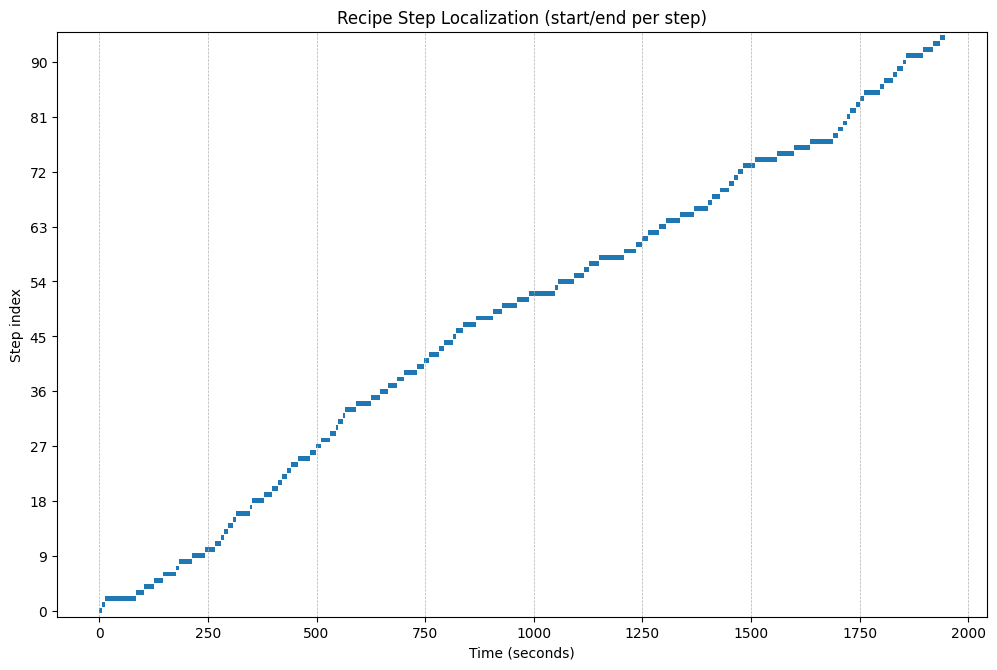

In [9]:
import numpy as np
import matplotlib.pyplot as plt

seg = d["segments_sec"]   # [N,2]
N = seg.shape[0]

starts = seg[:, 0]
ends = seg[:, 1]
durations = ends - starts

fig, ax = plt.subplots(figsize=(12, max(4, N * 0.08)))

# One horizontal bar per step
for i in range(N):
    ax.broken_barh([(starts[i], durations[i])], (i - 0.4, 0.8))

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Step index")
ax.set_title("Recipe Step Localization (start/end per step)")
ax.set_yticks(range(0, N, max(1, N // 10)))
ax.set_ylim(-1, N)
ax.grid(True, axis="x", linestyle="--", linewidth=0.5)
plt.show()


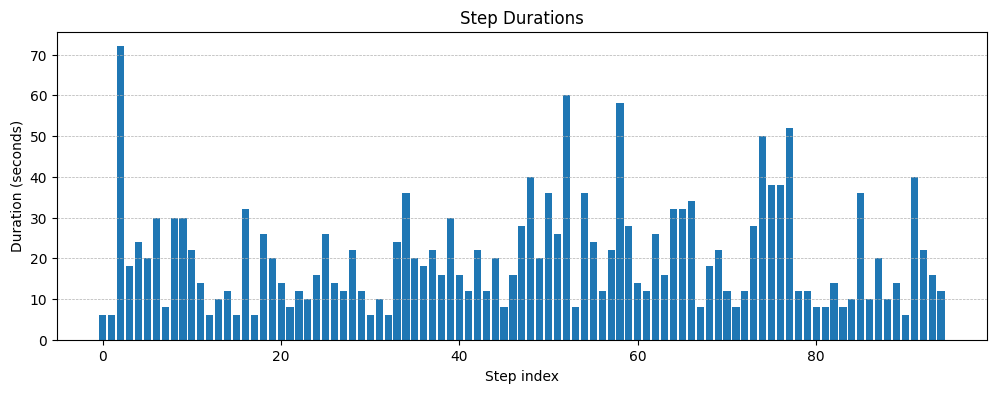

In [10]:
import numpy as np
import matplotlib.pyplot as plt

seg = d["segments_sec"]
dur = seg[:, 1] - seg[:, 0]

plt.figure(figsize=(12, 4))
plt.bar(np.arange(len(dur)), dur)
plt.xlabel("Step index")
plt.ylabel("Duration (seconds)")
plt.title("Step Durations")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.show()


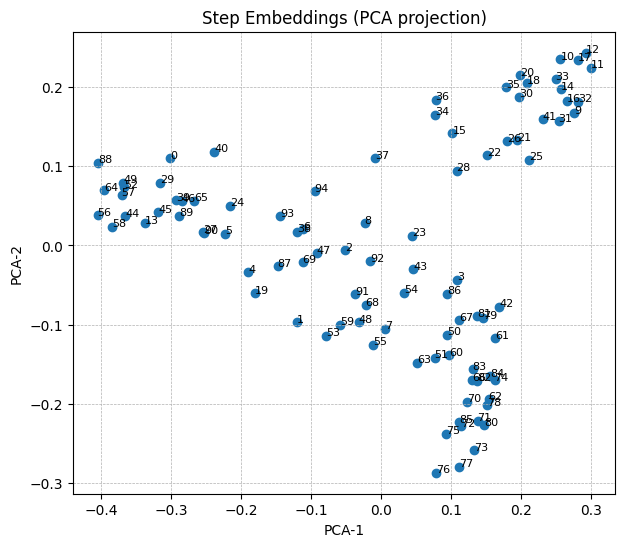

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

emb = d["step_embeddings"]  # [N, D]

# L2 normalize (good practice for cosine-style embeddings)
emb_norm = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)

pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(emb_norm)

plt.figure(figsize=(7, 6))
plt.scatter(xy[:, 0], xy[:, 1])
for i in range(len(xy)):
    plt.text(xy[i, 0], xy[i, 1], str(i), fontsize=8)

plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("Step Embeddings (PCA projection)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()


# **fixing csv file by using annotations of captaincook**

In [12]:
import os, glob, re
from pathlib import Path
import pandas as pd

# =========================
# EDIT THESE PATHS
# =========================
EMB_DIR = "/content/drive/My Drive/AML_Project/step_level_features"  # folder containing *_steps.npz
OUT_CSV = "/content/drive/My Drive/AML_Project/task_verification_labels.csv"

# Find embedding outputs from Substep 1
npz_files = sorted(glob.glob(os.path.join(EMB_DIR, "*_steps.npz")))
if len(npz_files) == 0:
    raise RuntimeError(f"No *_steps.npz files found in: {EMB_DIR}")

def video_id_from_npz(path: str) -> str:
    return Path(path).name.replace("_steps.npz", "")

def guess_recipe_id(video_id: str) -> str:
    """
    Best-effort heuristic. You will still likely need to edit recipe_id manually.
    For your names like: 10_16_360p_224 -> guess recipe_id = 10 (prefix before first underscore)
    """
    # Example: "10_16_360p_224" -> "10"
    if "_" in video_id:
        return video_id.split("_")[0]
    return video_id

rows = []
for p in npz_files:
    vid = video_id_from_npz(p)
    rows.append({
        "video_id": vid,
        "recipe_id": guess_recipe_id(vid),  # you can edit this column later if wrong
        "label": -1,                        # TODO: set to 1 (correct) or 0 (incorrect)
        "emb_path": p                       # helpful for debugging
    })

df = pd.DataFrame(rows).sort_values(["recipe_id", "video_id"]).reset_index(drop=True)
os.makedirs(str(Path(OUT_CSV).parent), exist_ok=True)
df.to_csv(OUT_CSV, index=False)

print(f"✅ Wrote CSV template with {len(df)} videos:")
print(" ", OUT_CSV)
display(df.head(20))

print("\nNow open the CSV in Drive and fill:")
print("- recipe_id: grouping key for leave-one-recipe-out (all videos of same recipe share same id)")
print("- label: 1 correct, 0 incorrect")
print("Then run Cell B.")


✅ Wrote CSV template with 384 videos:
  /content/drive/My Drive/AML_Project/task_verification_labels.csv


,video_id,recipe_id,label,emb_path
0,1_10_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
1,1_136_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
2,1_143_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
3,1_14_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
4,1_19_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
5,1_20_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
6,1_25_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
7,1_28_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
8,1_30_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...
9,1_32_360p_224,1,-1,/content/drive/My Drive/AML_Project/step_level...



Now open the CSV in Drive and fill:
- recipe_id: grouping key for leave-one-recipe-out (all videos of same recipe share same id)
- label: 1 correct, 0 incorrect
Then run Cell B.


In [13]:
import os, glob, zipfile
from pathlib import Path
import pandas as pd
import numpy as np

# =========================
# EDIT THESE PATHS
# =========================
ANNOT_ZIP = "/content/drive/My Drive/AML_Project/annotations.zip"  # upload/copy your zip to Drive
EMB_DIR   = "/content/drive/My Drive/AML_Project/step_level_features"  # where *_steps.npz are
OUT_CSV   = "/content/drive/My Drive/AML_Project/task_verification_labels.csv"

# Where to unzip in Colab runtime
UNZIP_DIR = "/content/captaincook_annotations"

# 1) Unzip
os.makedirs(UNZIP_DIR, exist_ok=True)
with zipfile.ZipFile(ANNOT_ZIP, "r") as z:
    z.extractall(UNZIP_DIR)

# 2) Load error annotations CSV
ERR_CSV = os.path.join(UNZIP_DIR, "annotations", "annotation_csv", "error_annotations.csv")
err = pd.read_csv(ERR_CSV)

# 3) Compute "any error" per recording_id
# Prefer has_errors if present; otherwise use any of the error category columns
if "has_errors" in err.columns:
    any_err = err.groupby("recording_id")["has_errors"].max().astype(bool)
else:
    # all numeric error-type columns except timing fields/text
    ignore = {"recording_id","step_id","start_time","end_time","description"}
    error_cols = [c for c in err.columns if c not in ignore and err[c].dtype != "object"]
    any_err = (err.groupby("recording_id")[error_cols].max().sum(axis=1) > 0)

rec_to_label = (1 - any_err.astype(int)).to_dict()  # 1=correct, 0=incorrect

# 4) Map your embedding filenames -> recording_id used in annotations
npz_files = sorted(glob.glob(os.path.join(EMB_DIR, "*_steps.npz")))
if len(npz_files) == 0:
    raise RuntimeError(f"No *_steps.npz found in {EMB_DIR}")

def video_id_from_npz(p):
    return Path(p).name.replace("_steps.npz", "")

def recording_id_from_video_id(video_id: str) -> str:
    """
    Your video ids look like:
      10_16_360p_224  -> recording_id = 10_16
      1_10_360p_224   -> recording_id = 1_10
    We take the first two '_' tokens.
    """
    parts = video_id.split("_")
    if len(parts) < 2:
        return video_id
    return f"{parts[0]}_{parts[1]}"

rows = []
missing = []
for p in npz_files:
    vid = video_id_from_npz(p)
    rec_id = recording_id_from_video_id(vid)
    if rec_id not in rec_to_label:
        missing.append((vid, rec_id))
        continue

    recipe_id = rec_id.split("_")[0]  # leave-one-out by recipe index
    rows.append({
        "video_id": vid,
        "recipe_id": recipe_id,
        "label": int(rec_to_label[rec_id]),  # 1 correct, 0 incorrect
        "emb_path": p,
        "recording_id": rec_id
    })

df = pd.DataFrame(rows).sort_values(["recipe_id","video_id"]).reset_index(drop=True)
df.to_csv(OUT_CSV, index=False)

print(f"✅ Wrote {OUT_CSV} with {len(df)} labeled videos.")
print(f"⚠️ Missing label matches for {len(missing)} embedding files.")
if missing:
    print("First 10 missing (video_id, derived recording_id):")
    for x in missing[:10]:
        print(" ", x)

display(df.head(10))
print("\nLabel distribution:")
print(df['label'].value_counts())


✅ Wrote /content/drive/My Drive/AML_Project/task_verification_labels.csv with 384 labeled videos.
⚠️ Missing label matches for 0 embedding files.


,video_id,recipe_id,label,emb_path,recording_id
0,1_10_360p_224,1,0,/content/drive/My Drive/AML_Project/step_level...,1_10
1,1_136_360p_224,1,0,/content/drive/My Drive/AML_Project/step_level...,1_136
2,1_143_360p_224,1,0,/content/drive/My Drive/AML_Project/step_level...,1_143
3,1_14_360p_224,1,1,/content/drive/My Drive/AML_Project/step_level...,1_14
4,1_19_360p_224,1,1,/content/drive/My Drive/AML_Project/step_level...,1_19
5,1_20_360p_224,1,1,/content/drive/My Drive/AML_Project/step_level...,1_20
6,1_25_360p_224,1,1,/content/drive/My Drive/AML_Project/step_level...,1_25
7,1_28_360p_224,1,0,/content/drive/My Drive/AML_Project/step_level...,1_28
8,1_30_360p_224,1,0,/content/drive/My Drive/AML_Project/step_level...,1_30
9,1_32_360p_224,1,0,/content/drive/My Drive/AML_Project/step_level...,1_32



Label distribution:
label
0    220
1    164
Name: count, dtype: int64


In [14]:
import pandas as pd

LABELS_PATH = "/content/drive/My Drive/AML_Project/task_verification_labels.csv"
df = pd.read_csv(LABELS_PATH)

print("Total videos:", len(df))
print("Recipes:", df["recipe_id"].nunique())
print("\nOverall label distribution:")
print(df["label"].value_counts())

print("\nPer-recipe label distribution (first 10 recipes):")
per = df.groupby("recipe_id")["label"].value_counts().unstack(fill_value=0)
display(per.head(10))
›

Total videos: 384
Recipes: 24

Overall label distribution:
label
0    220
1    164
Name: count, dtype: int64

Per-recipe label distribution (first 10 recipes):


label,0,1
recipe_id,,
1,13,5
2,10,6
3,8,5
4,7,10
5,7,8
7,10,6
8,10,6
9,5,9
10,8,4


# **step 2**

In [15]:
import os, glob, random
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# =========================
# PATHS (EDIT IF NEEDED)
# =========================
EMB_DIR = "/content/drive/My Drive/AML_Project/step_level_features"
LABELS_PATH = "/content/drive/My Drive/AML_Project/task_verification_labels.csv"

In [16]:
# =========================
# HYPERPARAMS
# =========================
SEED = 0
EPOCHS = 25
BATCH_SIZE = 8
LR = 3e-4
WEIGHT_DECAY = 1e-3
D_MODEL = 256
NHEAD = 4
NUM_LAYERS = 1
DROPOUT = 0.1
MAX_GRAD_NORM = 1.0

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- Load label CSV ----------
df_labels = pd.read_csv(LABELS_PATH)
df_labels["video_id"] = df_labels["video_id"].astype(str)
df_labels["recipe_id"] = df_labels["recipe_id"].astype(str)
df_labels["label"] = df_labels["label"].astype(int)



Device: cuda


In [17]:
# ---------- Index embedding files ----------
def video_id_from_npz(path: str) -> str:
    return Path(path).name.replace("_steps.npz", "")

npz_files = sorted(glob.glob(os.path.join(EMB_DIR, "*_steps.npz")))
emb_map = {video_id_from_npz(p): p for p in npz_files}

rows = []
for _, r in df_labels.iterrows():
    vid = r["video_id"]
    if vid in emb_map:
        rows.append({"video_id": vid, "recipe_id": r["recipe_id"], "label": int(r["label"]), "path": emb_map[vid]})

df_idx = pd.DataFrame(rows)
print("Usable videos:", len(df_idx), "| recipes:", df_idx["recipe_id"].nunique())
print(df_idx["label"].value_counts())


Usable videos: 384 | recipes: 24
label
0    220
1    164
Name: count, dtype: int64


In [18]:
# ---------- Dataset + collate ----------
class TaskVerificationDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        d = np.load(row["path"], allow_pickle=True)
        x = d["step_embeddings"].astype(np.float32)   # [T,D]
        y = np.float32(row["label"])
        return torch.from_numpy(x), torch.tensor(y), row["video_id"], row["recipe_id"]

def collate_pad(batch):
    xs, ys, vids, rids = zip(*batch)
    lens = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)
    D = xs[0].shape[1]
    T = int(lens.max().item())

    xpad = torch.zeros(len(xs), T, D, dtype=torch.float32)
    pad_mask = torch.ones(len(xs), T, dtype=torch.bool)  # True=PAD

    for i, x in enumerate(xs):
        t = x.shape[0]
        if t > 0:
            xpad[i, :t] = x
            pad_mask[i, :t] = False

    y = torch.stack(ys).float()
    return xpad, pad_mask, y, list(vids), list(rids)


In [19]:
# ---------- Model ----------
class StepTransformerVerifier(nn.Module):
    def __init__(self, d_in, d_model=256, nhead=4, num_layers=1, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(d_in, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x, pad_mask):
        h = self.proj(x)
        h = self.enc(h, src_key_padding_mask=pad_mask)  # [B,T,d_model]
        valid = (~pad_mask).unsqueeze(-1).float()
        denom = valid.sum(dim=1).clamp_min(1.0)
        pooled = (h * valid).sum(dim=1) / denom
        return self.head(pooled).squeeze(-1)

def compute_metrics(y_true, y_prob, thresh=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thresh).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = float("nan")
    return {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    ys, probs = [], []
    for xpad, pad_mask, y, vids, rids in loader:
        xpad = xpad.to(device)
        pad_mask = pad_mask.to(device)
        logits = model(xpad, pad_mask)
        prob = torch.sigmoid(logits).cpu().numpy()
        probs.extend(prob.tolist())
        ys.extend(y.numpy().tolist())
    return ys, probs

def train_one_fold(train_df, test_df):
    # infer input dim
    sample = np.load(train_df.iloc[0]["path"], allow_pickle=True)["step_embeddings"]
    d_in = sample.shape[1]

    model = StepTransformerVerifier(d_in, D_MODEL, NHEAD, NUM_LAYERS, DROPOUT).to(device)

    # imbalance weighting
    y_train = train_df["label"].values.astype(int)
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    pos_weight = torch.tensor((n_neg / max(n_pos, 1)) if n_pos > 0 else 1.0, device=device)

    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    train_loader = DataLoader(TaskVerificationDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, collate_fn=collate_pad)
    test_loader  = DataLoader(TaskVerificationDataset(test_df), batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, collate_fn=collate_pad)

    best_state, best_f1 = None, -1.0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xpad, pad_mask, y, vids, rids in train_loader:
            xpad = xpad.to(device)
            pad_mask = pad_mask.to(device)
            y = y.to(device)

            opt.zero_grad(set_to_none=True)
            logits = model(xpad, pad_mask)
            loss = crit(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            opt.step()

        # pick best epoch by train F1
        tr_y, tr_p = eval_model(model, train_loader)
        tr_m = compute_metrics(tr_y, tr_p)
        if tr_m["f1"] > best_f1:
            best_f1 = tr_m["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch in {1, 5, 10, 15, 20, 25}:
            print(f"  epoch {epoch:02d} | train f1 {tr_m['f1']:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    te_y, te_p = eval_model(model, test_loader)
    te_m = compute_metrics(te_y, te_p)
    return te_m, te_y, te_p



In [20]:
recipes = sorted(df_idx["recipe_id"].unique().tolist())
print("Leave-one-recipe-out folds:", len(recipes))

fold_rows, pred_rows = [], []

for rid in recipes:
    test_df = df_idx[df_idx["recipe_id"] == rid].copy()
    train_df = df_idx[df_idx["recipe_id"] != rid].copy()
    if len(test_df) == 0 or len(train_df) < 2:
        continue

    print(f"\n=== Hold out recipe {rid} | train={len(train_df)} test={len(test_df)} ===")
    m, y_true, y_prob = train_one_fold(train_df, test_df)

    fold_rows.append({"heldout_recipe": rid, "n_train": len(train_df), "n_test": len(test_df), **m})
    for vid, yt, yp in zip(test_df["video_id"].tolist(), y_true, y_prob):
        pred_rows.append({"recipe_id": rid, "video_id": vid, "y_true": int(yt), "y_prob": float(yp)})

results_df = pd.DataFrame(fold_rows)
preds_df = pd.DataFrame(pred_rows)

print("\nPer-fold metrics:")
display(results_df)

print("\nMean across folds:")
display(results_df[["acc","precision","recall","f1","auc"]].mean(numeric_only=True))




Leave-one-recipe-out folds: 24

=== Hold out recipe 1 | train=366 test=18 ===


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  epoch 01 | train f1 0.606
  epoch 05 | train f1 0.637
  epoch 10 | train f1 0.833
  epoch 15 | train f1 0.918
  epoch 20 | train f1 0.974
  epoch 25 | train f1 1.000

=== Hold out recipe 10 | train=372 test=12 ===
  epoch 01 | train f1 0.602
  epoch 05 | train f1 0.706
  epoch 10 | train f1 0.868
  epoch 15 | train f1 0.978
  epoch 20 | train f1 1.000
  epoch 25 | train f1 1.000

=== Hold out recipe 12 | train=366 test=18 ===
  epoch 01 | train f1 0.110
  epoch 05 | train f1 0.693
  epoch 10 | train f1 0.877
  epoch 15 | train f1 0.990
  epoch 20 | train f1 0.997
  epoch 25 | train f1 0.990

=== Hold out recipe 13 | train=370 test=14 ===
  epoch 01 | train f1 0.049
  epoch 05 | train f1 0.603
  epoch 10 | train f1 0.887
  epoch 15 | train f1 0.950
  epoch 20 | train f1 0.994
  epoch 25 | train f1 1.000

=== Hold out recipe 15 | train=369 test=15 ===
  epoch 01 | train f1 0.573
  epoch 05 | train f1 0.662
  epoch 10 | train f1 0.899
  epoch 15 | train f1 0.991
  epoch 20 | train f1 0.

,heldout_recipe,n_train,n_test,acc,precision,recall,f1,auc
0,1,366,18,0.777778,0.600000,0.600000,0.600000,0.584615
1,10,372,12,0.500000,0.375000,0.750000,0.500000,0.468750
2,12,366,18,0.555556,0.800000,0.363636,0.500000,0.545455
3,13,370,14,0.642857,0.500000,0.800000,0.615385,0.666667
4,15,369,15,0.666667,0.500000,0.600000,0.545455,0.600000
5,16,368,16,0.500000,0.333333,0.333333,0.333333,0.516667
6,17,364,20,0.450000,0.571429,0.333333,0.421053,0.354167
7,18,369,15,0.800000,0.600000,0.750000,0.666667,0.727273
8,2,368,16,0.500000,0.400000,0.666667,0.500000,0.575000
9,20,370,14,0.500000,0.428571,0.500000,0.461538,0.479167



Mean across folds:


,0
acc,0.603767
precision,0.527975
recall,0.576858
f1,0.534167
auc,0.585217


In [21]:
# Save outputs
OUT_METRICS = os.path.join(EMB_DIR, "substep2_leave_one_recipe_out_metrics.csv")
OUT_PREDS   = os.path.join(EMB_DIR, "substep2_leave_one_recipe_out_predictions.csv")
results_df.to_csv(OUT_METRICS, index=False)
preds_df.to_csv(OUT_PREDS, index=False)

print("\nSaved:")
print(" ", OUT_METRICS)
print(" ", OUT_PREDS)


Saved:
  /content/drive/My Drive/AML_Project/step_level_features/substep2_leave_one_recipe_out_metrics.csv
  /content/drive/My Drive/AML_Project/step_level_features/substep2_leave_one_recipe_out_predictions.csv


In [22]:
import os
import pandas as pd

EMB_DIR = "/content/drive/My Drive/AML_Project/step_level_features"  # EDIT if needed

METRICS_CSV = os.path.join(EMB_DIR, "substep2_leave_one_recipe_out_metrics.csv")
PREDS_CSV   = os.path.join(EMB_DIR, "substep2_leave_one_recipe_out_predictions.csv")

results_df = pd.read_csv(METRICS_CSV)
preds_df   = pd.read_csv(PREDS_CSV)

print("Loaded metrics:", results_df.shape)
print("Loaded preds:", preds_df.shape)
display(results_df.head())
display(preds_df.head())


Loaded metrics: (24, 8)
Loaded preds: (384, 4)


,heldout_recipe,n_train,n_test,acc,precision,recall,f1,auc
0,1,366,18,0.777778,0.600,0.600000,0.600000,0.584615
1,10,372,12,0.500000,0.375,0.750000,0.500000,0.468750
2,12,366,18,0.555556,0.800,0.363636,0.500000,0.545455
3,13,370,14,0.642857,0.500,0.800000,0.615385,0.666667
4,15,369,15,0.666667,0.500,0.600000,0.545455,0.600000


,recipe_id,video_id,y_true,y_prob
0,1,1_10_360p_224,0,0.003881
1,1,1_136_360p_224,0,0.999551
2,1,1_143_360p_224,0,0.000619
3,1,1_14_360p_224,1,0.000077
4,1,1_19_360p_224,1,0.000077


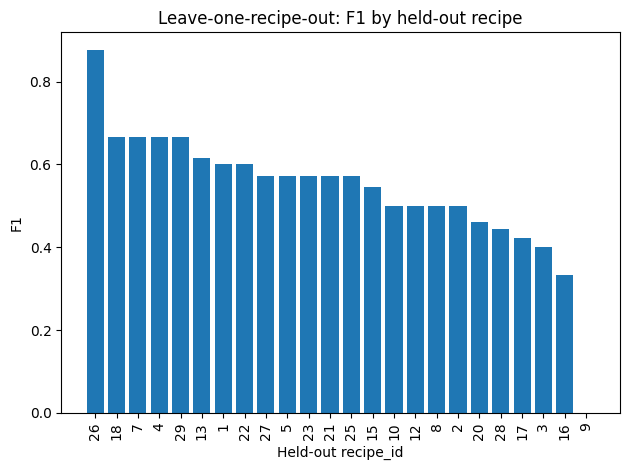

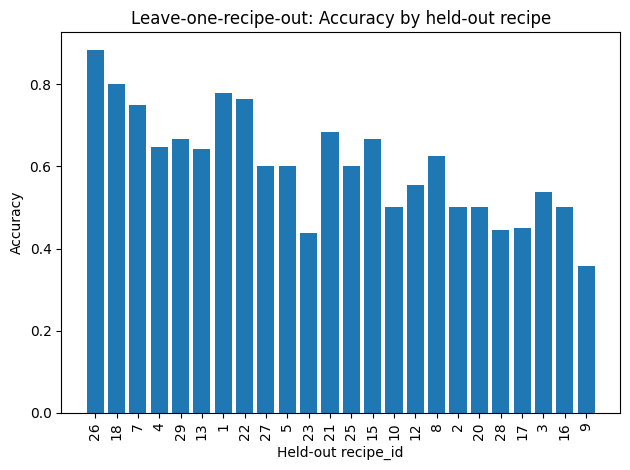

In [23]:
import matplotlib.pyplot as plt

df = results_df.copy().sort_values("f1", ascending=False)

plt.figure()
plt.bar(df["heldout_recipe"].astype(str), df["f1"])
plt.xticks(rotation=90)
plt.title("Leave-one-recipe-out: F1 by held-out recipe")
plt.xlabel("Held-out recipe_id")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(df["heldout_recipe"].astype(str), df["acc"])
plt.xticks(rotation=90)
plt.title("Leave-one-recipe-out: Accuracy by held-out recipe")
plt.xlabel("Held-out recipe_id")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()


/tmp/ipython-input-4224773386.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=metrics)


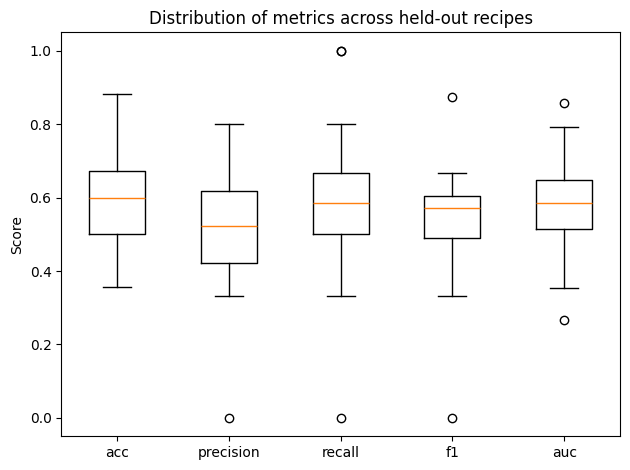

In [24]:
import matplotlib.pyplot as plt

metrics = ["acc", "precision", "recall", "f1", "auc"]
data = [results_df[m].dropna().values for m in metrics]

plt.figure()
plt.boxplot(data, labels=metrics)
plt.title("Distribution of metrics across held-out recipes")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


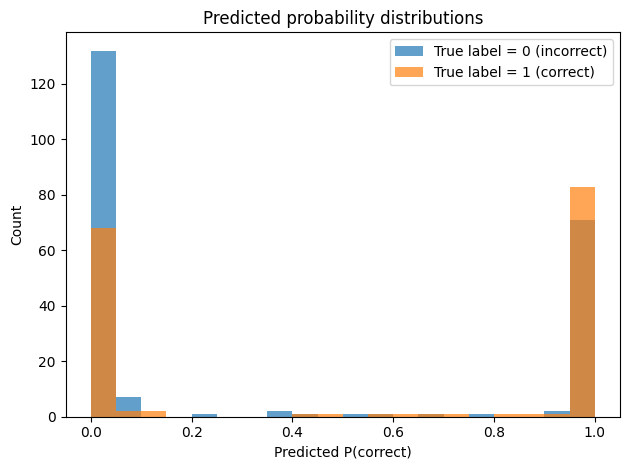

In [25]:
import numpy as np
import matplotlib.pyplot as plt

y0 = preds_df[preds_df["y_true"] == 0]["y_prob"].values
y1 = preds_df[preds_df["y_true"] == 1]["y_prob"].values

plt.figure()
plt.hist(y0, bins=20, alpha=0.7, label="True label = 0 (incorrect)")
plt.hist(y1, bins=20, alpha=0.7, label="True label = 1 (correct)")
plt.title("Predicted probability distributions")
plt.xlabel("Predicted P(correct)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


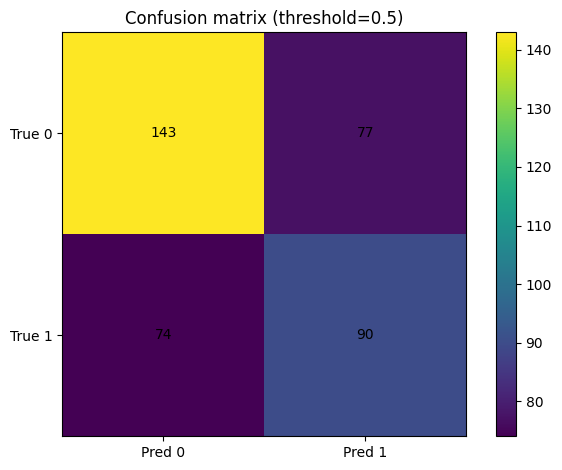

TN, FP, FN, TP = 143 77 74 90


In [26]:
import matplotlib.pyplot as plt
import numpy as np

thr = 0.5
y_true = preds_df["y_true"].astype(int).values
y_pred = (preds_df["y_prob"].values >= thr).astype(int)

tn = int(((y_true == 0) & (y_pred == 0)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
tp = int(((y_true == 1) & (y_pred == 1)).sum())

cm = np.array([[tn, fp],
               [fn, tp]])

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion matrix (threshold={thr})")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

print("TN, FP, FN, TP =", tn, fp, fn, tp)


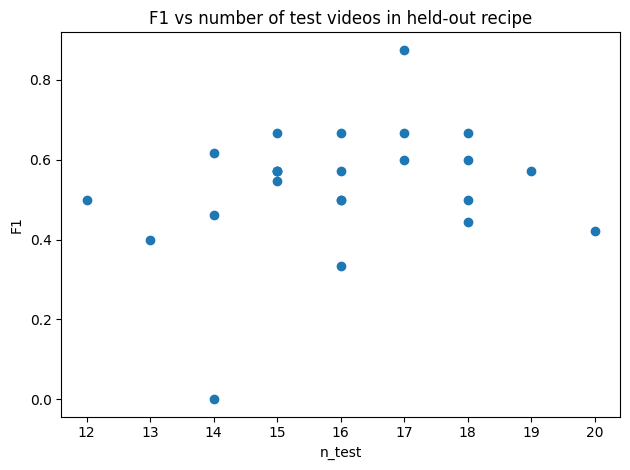

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(results_df["n_test"], results_df["f1"])
plt.title("F1 vs number of test videos in held-out recipe")
plt.xlabel("n_test")
plt.ylabel("F1")
plt.tight_layout()
plt.show()


# **step 3**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install scipy open_clip_torch


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


In [2]:
#Cell 1 — Paths + unzip annotations
import os, glob, json, zipfile, re
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# EDIT THESE IF NEEDED
# =========================
ANNOT_ZIP = "/content/drive/My Drive/AML_Project/annotations.zip"

# Your Substep-1 outputs (the step-level embeddings you already computed)
STEP_LEVEL_DIR = "/content/drive/My Drive/AML_Project/step_level_features"  # contains *_steps.npz

# Your EgoVLP dense per-video features (clip/frame features). You gave this path:
EGOVLP_DENSE_DIR = "/content/drive/My Drive/egovlp/features/egovlp"

# Output folder for Substep-3 artifacts
OUT_DIR = "/content/drive/My Drive/AML_Project/substep3_matching"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "graphs"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "videos"), exist_ok=True)

# unzip annotations to local runtime for speed
UNZIP_DIR = "/content/captaincook_annotations"
if not os.path.exists(UNZIP_DIR):
    os.makedirs(UNZIP_DIR, exist_ok=True)
    with zipfile.ZipFile(ANNOT_ZIP, "r") as z:
        z.extractall(UNZIP_DIR)

print("✅ Unzipped annotations to:", UNZIP_DIR)


✅ Unzipped annotations to: /content/captaincook_annotations


In [3]:
#Cell 2 — Load task graphs + auto-map recipe_id → graph_name
import collections

TASK_GRAPHS_DIR = os.path.join(UNZIP_DIR, "annotations", "task_graphs")
ANN_JSON_DIR    = os.path.join(UNZIP_DIR, "annotations", "annotation_json")
ANN_CSV_DIR     = os.path.join(UNZIP_DIR, "annotations", "annotation_csv")
META_DIR        = os.path.join(UNZIP_DIR, "annotations", "metadata")

# Load mapping recording_id -> list of GT step_ids (for auto mapping recipe -> graph)
with open(os.path.join(ANN_JSON_DIR, "recording_id_step_idx.json"), "r") as f:
    rec_steps = json.load(f)

with open(os.path.join(ANN_JSON_DIR, "step_idx_description.json"), "r") as f:
    step_desc = json.load(f)

# Load all graphs
graph_files = sorted(glob.glob(os.path.join(TASK_GRAPHS_DIR, "*.json")))
assert len(graph_files) == 24, f"Expected 24 task graphs, got {len(graph_files)}"

graphs = {}
graph_desc_sets = {}
for gf in graph_files:
    gname = Path(gf).stem
    g = json.load(open(gf, "r"))
    # g has {"steps": {node_id: text}, "edges": [[src,dst], ...]}
    graphs[gname] = g
    descs = set([v.strip() for v in g["steps"].values() if v not in ("START", "END")])
    graph_desc_sets[gname] = descs

# Build recipe_id -> set of GT step descriptions (from recordings)
recipe_to_desc = collections.defaultdict(set)
for recording_id, steps in rec_steps.items():
    recipe_id = recording_id.split("_")[0]  # numeric recipe index "1".."24"
    for s in steps:
        ds = step_desc.get(str(s))
        if ds:
            recipe_to_desc[recipe_id].add(ds.strip())

# Auto-map numeric recipe_id -> correct task-graph filename by exact description overlap
recipe_to_graph = {}
for recipe_id, descs in recipe_to_desc.items():
    best, bestscore = None, -1
    for gname, gdescs in graph_desc_sets.items():
        overlap = len(descs & gdescs)
        score = overlap / max(1, min(len(descs), len(gdescs)))
        if score > bestscore:
            bestscore = score
            best = gname
    recipe_to_graph[recipe_id] = best

print("✅ recipe_id -> task graph mapping (sample):")
for k in sorted(list(recipe_to_graph.keys()))[:10]:
    print(k, "->", recipe_to_graph[k])


✅ recipe_id -> task graph mapping (sample):
1 -> microwaveeggsandwich
10 -> pinwheels
12 -> tomatomozzarellasalad
13 -> buttercorncup
15 -> tomatochutney
16 -> scrambledeggs
17 -> cucumberraita
18 -> zoodles
2 -> dressedupmeatballs
20 -> sautedmushrooms


In [4]:
#Cell 3 — Load EgoVLP dense features + GT step annotations (for alignment)
# Load metadata: recording duration to map seconds -> feature indices
video_info = pd.read_csv(os.path.join(META_DIR, "video_information.csv"))
dur_sec = dict(zip(video_info["recording_id"].astype(str), video_info["duration(sec)"].astype(float)))

# Load ground-truth step annotations (has start_time/end_time + description)
step_ann = pd.read_csv(os.path.join(ANN_CSV_DIR, "step_annotations.csv"))
step_ann["recording_id"] = step_ann["recording_id"].astype(str)

print("step_annotations rows:", len(step_ann))
print(step_ann.head(3))


step_annotations rows: 5700
  recording_id  step_id  start_time  end_time  \
0          1_7        3       7.072    46.288   
1          1_7        1      50.264    82.310   
2          1_7        4      92.605   135.293   

                                         description  has_errors  
0  Coat -Coat a 6-oz. ramekin cup with cooking spray       False  
1               Pour-Pour 1 egg into the ramekin cup       False  
2  Microwave-Microwave the ramekin cup uncovered ...       False  


In [5]:
#Cell 4 — Text encoder (OpenCLIP) + learn text→video alignment W
import torch
import open_clip
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---- Text encoder (default: OpenCLIP) ----
model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
tokenizer = open_clip.get_tokenizer("ViT-B-32")
model = model.to(device).eval()

@torch.no_grad()
def encode_texts(text_list, batch_size=64):
    feats = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        tok = tokenizer(batch).to(device)
        f = model.encode_text(tok)
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu())
    return torch.cat(feats, dim=0).numpy()  # [N, Dt]

# ---- Find EgoVLP dense feature files ----
dense_files = sorted(glob.glob(os.path.join(EGOVLP_DENSE_DIR, "*.npy")))
if len(dense_files) == 0:
    raise RuntimeError(f"No .npy features found in {EGOVLP_DENSE_DIR}")

def recording_id_from_dense_filename(fp: str) -> str:
    # tries to extract leading "X_Y" from filename like "1_10_360p_224.npy"
    stem = Path(fp).stem
    m = re.match(r"^(\d+_\d+)", stem)
    return m.group(1) if m else stem

dense_map = {}
for fp in dense_files:
    rid = recording_id_from_dense_filename(fp)
    dense_map[rid] = fp

print("Dense feature files found:", len(dense_map))
print("Example:", list(dense_map.items())[:3])

# ---- Build paired dataset: (text_emb, video_step_emb) using GT step segments ----
pairs_text = []
pairs_vid  = []

# group step_ann by recording_id to load each dense feature once
for rid, df_r in tqdm(step_ann.groupby("recording_id"), total=step_ann["recording_id"].nunique()):
    if rid not in dense_map:
        continue
    if rid not in dur_sec:
        continue

    F = np.load(dense_map[rid]).astype(np.float32)  # [L, Dv]
    L, Dv = F.shape
    stride = dur_sec[rid] / max(L, 1)  # seconds per feature index

    for _, row in df_r.iterrows():
        s = float(row["start_time"])
        e = float(row["end_time"])
        desc = str(row["description"]).strip()

        si = int(np.floor(s / stride))
        ei = int(np.ceil(e / stride))
        si = max(0, min(L-1, si))
        ei = max(si+1, min(L, ei))

        seg = F[si:ei]
        v = seg.mean(axis=0)

        pairs_text.append(desc)
        pairs_vid.append(v)

pairs_vid = np.stack(pairs_vid, axis=0)  # [M, Dv]
print("Paired samples:", len(pairs_text), "| video dim:", pairs_vid.shape[1])

# Encode paired texts
pairs_txt_emb = encode_texts(pairs_text)  # [M, Dt]
Dt = pairs_txt_emb.shape[1]
print("Text dim:", Dt)

# ---- Learn ridge regression W:  text_emb @ W  ≈ video_emb ----
# W shape: [Dt, Dv]
lam = 1e-2
X = pairs_txt_emb  # [M, Dt]
Y = pairs_vid      # [M, Dv]

# closed-form ridge: W = (X^T X + lam I)^(-1) X^T Y
XtX = X.T @ X
W = np.linalg.solve(XtX + lam * np.eye(Dt, dtype=np.float32), X.T @ Y).astype(np.float32)

W_path = os.path.join(OUT_DIR, "W_text_to_video_ridge.npy")
np.save(W_path, W)
print("✅ Saved alignment matrix:", W_path)


Device: cpu


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Dense feature files found: 384
Example: [('10_16', '/content/drive/My Drive/egovlp/features/egovlp/10_16_360p_224.npy'), ('10_18', '/content/drive/My Drive/egovlp/features/egovlp/10_18_360p_224.npy'), ('10_24', '/content/drive/My Drive/egovlp/features/egovlp/10_24_360p_224.npy')]


100%|██████████| 384/384 [00:40<00:00,  9.52it/s]


Paired samples: 5700 | video dim: 768
Text dim: 512
✅ Saved alignment matrix: /content/drive/My Drive/AML_Project/substep3_matching/W_text_to_video_ridge.npy


In [6]:
#Cell 5 — Encode each task graph’s node texts → project into EgoVLP video space
def l2norm(x, eps=1e-8):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

graph_cache = {}

for recipe_id, gname in recipe_to_graph.items():
    g = graphs[gname]
    # nodes
    node_ids = sorted([int(k) for k in g["steps"].keys()])
    node_texts = [g["steps"][str(i)] for i in node_ids]

    # encode + project to EgoVLP space
    txt_emb = encode_texts(node_texts)        # [N, Dt]
    node_emb_vidspace = txt_emb @ W           # [N, Dv]
    node_emb_vidspace = l2norm(node_emb_vidspace)

    # edges to edge_index [2, E] in node-index space
    edges = np.array(g["edges"], dtype=int)   # each is [src, dst] in original node ids
    # map original node id -> position in node_ids
    id2pos = {nid: k for k, nid in enumerate(node_ids)}
    edge_index = np.array([[id2pos[s], id2pos[t]] for s, t in edges], dtype=int).T  # [2,E]

    graph_cache[recipe_id] = {
        "graph_name": gname,
        "node_ids": np.array(node_ids, dtype=int),
        "node_texts": node_texts,
        "node_emb": node_emb_vidspace.astype(np.float32),  # [N,Dv]
        "edge_index": edge_index.astype(np.int64),         # [2,E]
    }

    # save once per recipe
    out_g = os.path.join(OUT_DIR, "graphs", f"recipe_{recipe_id}_{gname}.npz")
    np.savez_compressed(
        out_g,
        recipe_id=recipe_id,
        graph_name=gname,
        node_ids=np.array(node_ids, dtype=int),
        edge_index=edge_index.astype(np.int64),
        node_emb=node_emb_vidspace.astype(np.float32),
    )

print("✅ Saved per-recipe graph embeddings to:", os.path.join(OUT_DIR, "graphs"))


✅ Saved per-recipe graph embeddings to: /content/drive/My Drive/AML_Project/substep3_matching/graphs


In [7]:
#Cell 6 — Hungarian matching for every video (Substep 1 → nodes)
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm

# where your step-level embeddings are
step_npzs = sorted(glob.glob(os.path.join(STEP_LEVEL_DIR, "*_steps.npz")))
if len(step_npzs) == 0:
    raise RuntimeError(f"No *_steps.npz found in {STEP_LEVEL_DIR}")

def video_id_from_steps_npz(fp: str) -> str:
    return Path(fp).name.replace("_steps.npz", "")

def recipe_id_from_video_id(vid: str) -> str:
    # your naming: "1_10_360p_224" -> recipe_id "1"
    return vid.split("_")[0]

def l2n(x, eps=1e-8):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

SIM_THRESHOLD = None  # set e.g. 0.15 to drop weak matches

summary_rows = []

for fp in tqdm(step_npzs):
    vid = video_id_from_steps_npz(fp)
    recipe_id = recipe_id_from_video_id(vid)

    if recipe_id not in graph_cache:
        continue

    data = np.load(fp, allow_pickle=True)
    V = data["step_embeddings"].astype(np.float32)  # [T, Dv]
    if V.ndim != 2 or V.shape[0] == 0:
        continue

    G = graph_cache[recipe_id]
    N_emb = G["node_emb"].astype(np.float32)  # [N, Dv]

    Vn = l2n(V)
    # (node_emb already l2-normalized)
    sim = Vn @ N_emb.T  # [T, N]
    cost = -sim

    r, c = linear_sum_assignment(cost)  # matches min(T,N) pairs

    T, N = sim.shape
    match_vis2node = np.full(T, -1, dtype=int)
    match_node2vis = np.full(N, -1, dtype=int)

    matched_sims = []
    for i, j in zip(r, c):
        if SIM_THRESHOLD is not None and sim[i, j] < SIM_THRESHOLD:
            continue
        match_vis2node[i] = j
        match_node2vis[j] = i
        matched_sims.append(float(sim[i, j]))

    # Build per-node matched visual features (zeros if unmatched)
    node_vis = np.zeros((N, V.shape[1]), dtype=np.float32)
    for j in range(N):
        i = match_node2vis[j]
        if i >= 0:
            node_vis[j] = V[i]

    # This is your “realized graph node input” for Substep 4:
    # concat(text_node_emb_in_video_space, matched_visual_emb)
    node_input = np.concatenate([N_emb, node_vis], axis=1).astype(np.float32)  # [N, 2Dv]

    out_v = os.path.join(OUT_DIR, "videos", f"{vid}_matched.npz")
    np.savez_compressed(
        out_v,
        video_id=vid,
        recipe_id=recipe_id,
        graph_name=G["graph_name"],
        node_ids=G["node_ids"],
        edge_index=G["edge_index"],
        match_vis2node=match_vis2node,
        match_node2vis=match_node2vis,
        node_text_emb=N_emb,      # [N,Dv]
        node_vis_emb=node_vis,    # [N,Dv]
        node_input=node_input,    # [N,2Dv]  (ready for GNN)
    )

    summary_rows.append({
        "video_id": vid,
        "recipe_id": recipe_id,
        "graph_name": G["graph_name"],
        "T_steps": T,
        "N_nodes": N,
        "n_matched": int((match_vis2node >= 0).sum()),
        "mean_matched_sim": float(np.mean(matched_sims)) if matched_sims else float("nan"),
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "substep3_matching_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("✅ Saved per-video matched graphs to:", os.path.join(OUT_DIR, "videos"))
print("✅ Saved summary:", summary_csv)
display(summary_df.head(10))
print(summary_df[["n_matched","mean_matched_sim"]].describe())


100%|██████████| 384/384 [05:30<00:00,  1.16it/s]


✅ Saved per-video matched graphs to: /content/drive/My Drive/AML_Project/substep3_matching/videos
✅ Saved summary: /content/drive/My Drive/AML_Project/substep3_matching/substep3_matching_summary.csv


,video_id,recipe_id,graph_name,T_steps,N_nodes,n_matched,mean_matched_sim
0,10_16_360p_224,10,pinwheels,95,21,21,0.931424
1,10_18_360p_224,10,pinwheels,69,21,21,0.948607
2,10_24_360p_224,10,pinwheels,73,21,21,0.918006
3,10_26_360p_224,10,pinwheels,53,21,21,0.920446
4,10_31_360p_224,10,pinwheels,44,21,21,0.930193
5,10_42_360p_224,10,pinwheels,94,21,21,0.945676
6,10_46_360p_224,10,pinwheels,80,21,21,0.927602
7,10_47_360p_224,10,pinwheels,53,21,21,0.927410
8,10_48_360p_224,10,pinwheels,74,21,21,0.932994
9,10_50_360p_224,10,pinwheels,29,21,21,0.921836


        n_matched  mean_matched_sim
count  384.000000        384.000000
mean    16.802083          0.938326
std      4.370253          0.013907
min      9.000000          0.854328
25%     13.000000          0.933519
50%     16.000000          0.941619
75%     20.000000          0.947755
max     27.000000          0.960421


A) Sanity-check your matching (correct vs wrong graph vs shuffled)
This code will:
load your per-video *_matched.npz
compute the mean cosine similarity of the matched pairs
compare it to:
wrong recipe graph (should drop a lot)
shuffled node embeddings (should drop a lot)
random pairing baseline
# If these “negative controls” don’t drop, you likely have an issue (e.g., embeddings reused, mismatch in files, or supervision leakage from learning a projection using GT descriptions). **bold text**

In [8]:
import os, glob
import numpy as np
import pandas as pd
from pathlib import Path

# EDIT if needed
OUT_DIR = "/content/drive/My Drive/AML_Project/substep3_matching"
VIDEOS_DIR = os.path.join(OUT_DIR, "videos")
SUMMARY_CSV = os.path.join(OUT_DIR, "substep3_matching_summary.csv")

def l2norm(x, eps=1e-8):
    n = np.linalg.norm(x, axis=1, keepdims=True) + eps
    return x / n

def mean_matched_cos(node_text_emb, node_vis_emb, match_node2vis):
    # compute cosine only for matched nodes
    # node_text_emb: [N,D], node_vis_emb: [N,D], match_node2vis: [N]
    Nt = l2norm(node_text_emb.astype(np.float32))
    Nv = l2norm(node_vis_emb.astype(np.float32))
    matched = (match_node2vis >= 0)
    if matched.sum() == 0:
        return np.nan
    cos = (Nt[matched] * Nv[matched]).sum(axis=1)
    return float(cos.mean())

print("VIDEOS_DIR:", VIDEOS_DIR)
print("SUMMARY_CSV exists:", os.path.exists(SUMMARY_CSV))


VIDEOS_DIR: /content/drive/My Drive/AML_Project/substep3_matching/videos
SUMMARY_CSV exists: True


In [9]:
import random

matched_files = sorted(glob.glob(os.path.join(VIDEOS_DIR, "*_matched.npz")))
if len(matched_files) == 0:
    raise RuntimeError(f"No *_matched.npz files found in {VIDEOS_DIR}")

print("Matched files:", len(matched_files))

# Load summary for recipe_id distribution / choosing wrong recipe
summary = pd.read_csv(SUMMARY_CSV) if os.path.exists(SUMMARY_CSV) else None

def load_npz(fp):
    d = np.load(fp, allow_pickle=True)
    return {
        "video_id": str(d["video_id"]),
        "recipe_id": str(d["recipe_id"]),
        "graph_name": str(d["graph_name"]),
        "node_text_emb": d["node_text_emb"],   # [N,D]
        "node_vis_emb": d["node_vis_emb"],     # [N,D]
        "match_node2vis": d["match_node2vis"], # [N]
    }

# Preload one example per recipe so we can use its node_text_emb as a "wrong graph"
recipe_example = {}
for fp in matched_files:
    d = load_npz(fp)
    if d["recipe_id"] not in recipe_example:
        recipe_example[d["recipe_id"]] = d["node_text_emb"]
    if len(recipe_example) >= 24:
        break

recipe_ids = sorted(list(recipe_example.keys()))
print("Recipes found in examples:", len(recipe_ids), recipe_ids[:10])

def pick_wrong_recipe(rid):
    others = [x for x in recipe_ids if x != rid]
    return random.choice(others) if others else rid

rows = []
random.seed(0)

# Evaluate on a subset (increase to full by setting MAX_N = len(matched_files))
MAX_N = min(200, len(matched_files))

for fp in random.sample(matched_files, MAX_N):
    d = load_npz(fp)
    Nt = d["node_text_emb"]
    Nv = d["node_vis_emb"]
    m  = d["match_node2vis"]

    # Correct matching score
    s_correct = mean_matched_cos(Nt, Nv, m)

    # Wrong recipe graph (same vis, but node_text from another recipe)
    wrong_rid = pick_wrong_recipe(d["recipe_id"])
    Nt_wrong = recipe_example[wrong_rid]
    # Need same N to compute per-node cos; easiest: compare mean best-match instead:
    # We'll do a simple "best cosine per vis step" proxy using node_vis_emb matched rows.
    # If N differs, skip node-wise mean and use global similarity mean.
    s_wrong = np.nan
    if Nt_wrong.shape[0] == Nt.shape[0] and Nt_wrong.shape[1] == Nt.shape[1]:
        s_wrong = mean_matched_cos(Nt_wrong, Nv, m)
    else:
        # fallback: compare mean cosine between matched visual rows and top-1 wrong nodes
        Vrows = l2norm(Nv[m >= 0])
        Tw = l2norm(Nt_wrong)
        sim = Vrows @ Tw.T
        s_wrong = float(sim.max(axis=1).mean()) if len(Vrows) else np.nan

    # Shuffled nodes (destroys correspondence)
    perm = np.random.permutation(Nt.shape[0])
    Nt_shuf = Nt[perm]
    s_shuf = mean_matched_cos(Nt_shuf, Nv, m)

    # Random pairing baseline: random node order (another shuffle)
    perm2 = np.random.permutation(Nt.shape[0])
    s_rand = mean_matched_cos(Nt[perm2], Nv, m)

    rows.append({
        "video_id": d["video_id"],
        "recipe_id": d["recipe_id"],
        "s_correct": s_correct,
        "s_wrong_graph": s_wrong,
        "s_shuffled": s_shuf,
        "s_random": s_rand
    })

df_chk = pd.DataFrame(rows)
display(df_chk.head())

print("\nMean scores over sample:")
print(df_chk[["s_correct","s_wrong_graph","s_shuffled","s_random"]].mean(numeric_only=True))
print("\nStd scores over sample:")
print(df_chk[["s_correct","s_wrong_graph","s_shuffled","s_random"]].std(numeric_only=True))


Matched files: 384
Recipes found in examples: 24 ['1', '10', '12', '13', '15', '16', '17', '18', '2', '20']


,video_id,recipe_id,s_correct,s_wrong_graph,s_shuffled,s_random
0,25_1_360p_224,25,0.948300,0.934102,0.923831,0.919052
1,26_24_360p_224,26,0.947516,0.941805,0.936297,0.937917
2,12_26_360p_224,12,0.937214,0.932227,0.910913,0.912218
3,20_22_360p_224,20,0.956155,0.957749,0.940436,0.939260
4,29_17_360p_224,29,0.932769,0.927794,0.920356,0.911876



Mean scores over sample:
s_correct        0.938868
s_wrong_graph    0.932321
s_shuffled       0.919166
s_random         0.919040
dtype: float64

Std scores over sample:
s_correct        0.012306
s_wrong_graph    0.013971
s_shuffled       0.013260
s_random         0.013572
dtype: float64


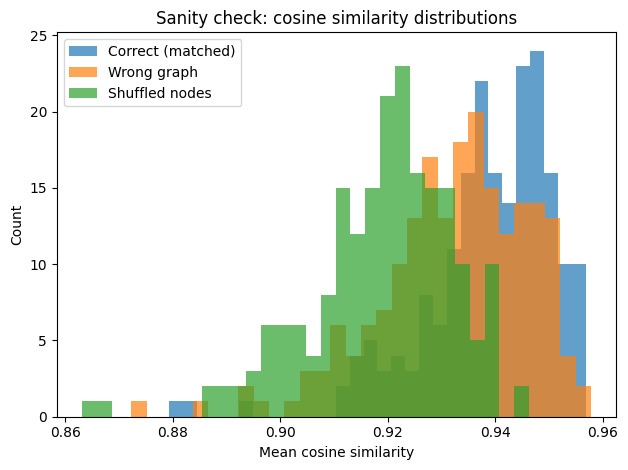

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_chk["s_correct"].dropna(), bins=30, alpha=0.7, label="Correct (matched)")
plt.hist(df_chk["s_wrong_graph"].dropna(), bins=30, alpha=0.7, label="Wrong graph")
plt.hist(df_chk["s_shuffled"].dropna(), bins=30, alpha=0.7, label="Shuffled nodes")
plt.title("Sanity check: cosine similarity distributions")
plt.xlabel("Mean cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# **What your numbers mean**
You got (means over sample):
correct: 0.9389
wrong graph: 0.9323 (only 0.0066 lower)
shuffled: 0.9193
random: 0.9193
That tells us:
Everything is very high (0.92–0.94), even wrong/shuffled.
The gap between correct vs wrong graph is tiny, which suggests the matching signal is weak or the embedding space is “collapsed” (most vectors are similar to most others).
Your current A2 check is also not a strict negative control, because it compares node_text_emb vs node_vis_emb after you already forced each node to get the “best” visual step.
So yes: this indicates a possible issue, and we should verify it properly.
✅ Do this proper verification (strong negative controls)
This version recomputes Hungarian matching from scratch using:
the raw visual step embeddings from Substep 1 (*_steps.npz)
the graph node embeddings (text) from Substep 3 (graphs/*.npz)
Then it compares:
correct recipe graph
wrong recipe graph
shuffled node embeddings
# random pairing baseline **bold text** **bold text**

In [11]:
#Cell 1 — Paths + helpers

import os, glob, re, random
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import linear_sum_assignment

# EDIT THESE IF NEEDED
STEP_LEVEL_DIR = "/content/drive/My Drive/AML_Project/step_level_features"      # *_steps.npz
SUBSTEP3_DIR   = "/content/drive/My Drive/AML_Project/substep3_matching"
GRAPHS_DIR     = os.path.join(SUBSTEP3_DIR, "graphs")
SUMMARY_CSV    = os.path.join(SUBSTEP3_DIR, "substep3_matching_summary.csv")

def l2norm(x, eps=1e-8):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def hungarian_mean_sim(V, N):
    """
    V: [T,D] visual steps
    N: [K,D] node text embeddings
    returns mean cosine similarity over matched pairs
    """
    Vn = l2norm(V.astype(np.float32))
    Nn = l2norm(N.astype(np.float32))
    sim = Vn @ Nn.T             # [T,K]
    cost = -sim
    r, c = linear_sum_assignment(cost)
    return float(sim[r, c].mean()), int(len(r))

def random_pairing_mean_sim(V, N, n_pairs):
    Vn = l2norm(V.astype(np.float32))
    Nn = l2norm(N.astype(np.float32))
    T, K = Vn.shape[0], Nn.shape[0]
    n_pairs = min(n_pairs, T, K)
    ridx = np.random.choice(T, size=n_pairs, replace=False)
    cidx = np.random.choice(K, size=n_pairs, replace=False)
    return float((Vn[ridx] * Nn[cidx]).sum(axis=1).mean())

print("STEP_LEVEL_DIR:", STEP_LEVEL_DIR)
print("GRAPHS_DIR:", GRAPHS_DIR)


STEP_LEVEL_DIR: /content/drive/My Drive/AML_Project/step_level_features
GRAPHS_DIR: /content/drive/My Drive/AML_Project/substep3_matching/graphs


In [12]:
#Cell 2 — Load graph embeddings per recipe_id

graph_files = sorted(glob.glob(os.path.join(GRAPHS_DIR, "recipe_*_*.npz")))
if len(graph_files) == 0:
    raise RuntimeError(f"No graph npz files found in {GRAPHS_DIR}")

recipe_to_graph = {}
for fp in graph_files:
    # filename like recipe_1_<graphname>.npz
    m = re.search(r"recipe_(\d+)_", Path(fp).name)
    if not m:
        continue
    rid = m.group(1)
    d = np.load(fp, allow_pickle=True)
    recipe_to_graph[rid] = d["node_emb"]   # [N,D]

recipe_ids = sorted(recipe_to_graph.keys(), key=lambda x: int(x))
print("Loaded graphs for recipes:", len(recipe_ids), recipe_ids[:10])


Loaded graphs for recipes: 24 ['1', '2', '3', '4', '5', '7', '8', '9', '10', '12']


In [13]:
#Cell 3 — Evaluate proper controls on a random subset
step_files = sorted(glob.glob(os.path.join(STEP_LEVEL_DIR, "*_steps.npz")))
if len(step_files) == 0:
    raise RuntimeError(f"No *_steps.npz files found in {STEP_LEVEL_DIR}")

def video_id_from_steps(fp):
    return Path(fp).name.replace("_steps.npz", "")

def recipe_id_from_video_id(vid):
    # Your naming: "1_10_360p_224" -> recipe_id "1"
    return vid.split("_")[0]

def pick_wrong_recipe(rid):
    others = [x for x in recipe_ids if x != rid]
    return random.choice(others)

random.seed(0)
np.random.seed(0)

MAX_N = min(200, len(step_files))   # set to len(step_files) if you want full eval
sample_files = random.sample(step_files, MAX_N)

rows = []
for fp in sample_files:
    vid = video_id_from_steps(fp)
    rid = recipe_id_from_video_id(vid)
    if rid not in recipe_to_graph:
        continue

    data = np.load(fp, allow_pickle=True)
    V = data["step_embeddings"]     # [T,D]

    N_correct = recipe_to_graph[rid]
    rid_wrong = pick_wrong_recipe(rid)
    N_wrong = recipe_to_graph[rid_wrong]

    s_correct, nmatch = hungarian_mean_sim(V, N_correct)
    s_wrong, _       = hungarian_mean_sim(V, N_wrong)

    # shuffled node embeddings (destroys node identity but keeps distribution)
    perm = np.random.permutation(N_correct.shape[0])
    s_shuf, _ = hungarian_mean_sim(V, N_correct[perm])

    # random pairing baseline
    s_rand = random_pairing_mean_sim(V, N_correct, nmatch)

    rows.append({
        "video_id": vid,
        "recipe_id": rid,
        "wrong_recipe": rid_wrong,
        "s_correct": s_correct,
        "s_wrong_graph": s_wrong,
        "s_shuffled": s_shuf,
        "s_random_pairing": s_rand,
        "T_steps": V.shape[0],
        "N_nodes": N_correct.shape[0],
    })

df = pd.DataFrame(rows)
display(df.head())

print("\nMEAN:")
print(df[["s_correct","s_wrong_graph","s_shuffled","s_random_pairing"]].mean())
print("\nSTD:")
print(df[["s_correct","s_wrong_graph","s_shuffled","s_random_pairing"]].std())


,video_id,recipe_id,wrong_recipe,s_correct,s_wrong_graph,s_shuffled,s_random_pairing,T_steps,N_nodes
0,25_1_360p_224,25,7,0.948300,0.940102,0.948300,0.878836,164,21
1,26_24_360p_224,26,7,0.947516,0.942262,0.947516,0.892749,102,22
2,12_26_360p_224,12,15,0.937215,0.916891,0.937215,0.885120,34,11
3,20_22_360p_224,20,22,0.956156,0.945475,0.956156,0.899104,84,20
4,29_17_360p_224,29,10,0.932769,0.915190,0.932769,0.849767,114,13



MEAN:
s_correct           0.938868
s_wrong_graph       0.928598
s_shuffled          0.938868
s_random_pairing    0.878928
dtype: float64

STD:
s_correct           0.012306
s_wrong_graph       0.014210
s_shuffled          0.012306
s_random_pairing    0.017881
dtype: float64


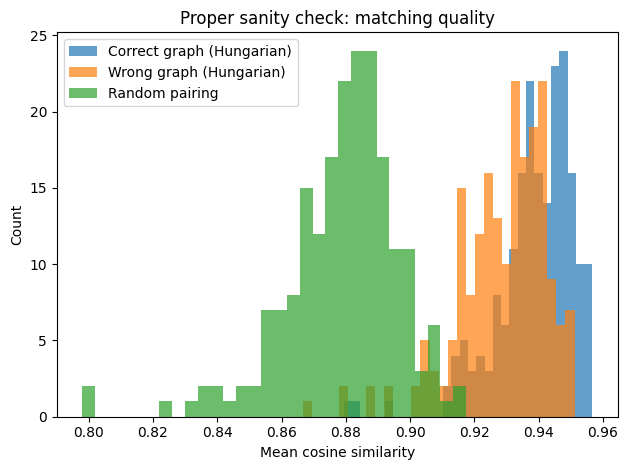

In [14]:
#Cell 4 — Plot distributions
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["s_correct"], bins=30, alpha=0.7, label="Correct graph (Hungarian)")
plt.hist(df["s_wrong_graph"], bins=30, alpha=0.7, label="Wrong graph (Hungarian)")
plt.hist(df["s_random_pairing"], bins=30, alpha=0.7, label="Random pairing")
plt.title("Proper sanity check: matching quality")
plt.xlabel("Mean cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


What your results mean
1) s_shuffled == s_correct is expected (not a bug)
You shuffled the order of node embeddings inside the same graph. That only permutes columns of the similarity matrix. Hungarian finds the same best set of pairs, so the optimal mean similarity stays identical.
So this control cannot detect problems with node identity. It’s fine that it matches.
2) The main concern: correct vs wrong graph are too close
Your means:
s_correct ≈ 0.9389
s_wrong_graph ≈ 0.9286 → gap ≈ 0.0103
random pairing ≈ 0.8789 (good: random is much lower)
So: matching is not random, but it’s also not very recipe-specific (wrong recipe graph still scores very high).
This can happen if:
your text→video alignment mapping is too “global” (maps most texts into a similar region),
many recipes share generic step language (“cut”, “mix”, “add”, “stir”),
or there is some leakage from training the mapping on all recipes.
✅ The best next sanity check (strong): “Graph retrieval accuracy”
Instead of just comparing “correct vs one wrong”, do this:
For each video, score it against ALL recipe graphs, pick the best one, and see if the correct recipe graph is ranked #1.
If alignment is meaningful, you should get accuracy way above chance (chance is about 1/24 ≈ 4%).

In [15]:
#Code: recipe graph retrieval accuracy (Colab)
import os, glob, re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import linear_sum_assignment

STEP_LEVEL_DIR = "/content/drive/My Drive/AML_Project/step_level_features"
SUBSTEP3_DIR   = "/content/drive/My Drive/AML_Project/substep3_matching"
GRAPHS_DIR     = os.path.join(SUBSTEP3_DIR, "graphs")

def l2norm(x, eps=1e-8):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def hungarian_mean_sim(V, N):
    Vn = l2norm(V.astype(np.float32))
    Nn = l2norm(N.astype(np.float32))
    sim = Vn @ Nn.T
    r, c = linear_sum_assignment(-sim)
    return float(sim[r, c].mean())

# Load graphs
graph_files = sorted(glob.glob(os.path.join(GRAPHS_DIR, "recipe_*_*.npz")))
recipe_to_nodeemb = {}
for fp in graph_files:
    m = re.search(r"recipe_(\d+)_", Path(fp).name)
    if not m:
        continue
    rid = m.group(1)
    d = np.load(fp, allow_pickle=True)
    recipe_to_nodeemb[rid] = d["node_emb"]

recipe_ids = sorted(recipe_to_nodeemb.keys(), key=lambda x: int(x))
print("Graphs loaded:", len(recipe_ids))

# Step files
step_files = sorted(glob.glob(os.path.join(STEP_LEVEL_DIR, "*_steps.npz")))
print("Videos found:", len(step_files))

def video_id_from_steps(fp):
    return Path(fp).name.replace("_steps.npz","")

def recipe_id_from_video_id(vid):
    return vid.split("_")[0]

# Evaluate on a subset or all
MAX_N = min(200, len(step_files))  # set to len(step_files) for full run
np.random.seed(0)
sample_files = np.random.choice(step_files, size=MAX_N, replace=False)

top1_correct = 0
top5_correct = 0
rows = []

for fp in sample_files:
    vid = video_id_from_steps(fp)
    rid_true = recipe_id_from_video_id(vid)
    if rid_true not in recipe_to_nodeemb:
        continue

    V = np.load(fp, allow_pickle=True)["step_embeddings"]

    # score against ALL graphs
    scores = []
    for rid in recipe_ids:
        N = recipe_to_nodeemb[rid]
        s = hungarian_mean_sim(V, N)
        scores.append((rid, s))

    scores.sort(key=lambda x: x[1], reverse=True)
    ranked = [r for r,_ in scores]

    if ranked[0] == rid_true:
        top1_correct += 1
    if rid_true in ranked[:5]:
        top5_correct += 1

    rows.append({
        "video_id": vid,
        "true_recipe": rid_true,
        "pred_recipe_top1": ranked[0],
        "score_true": dict(scores)[rid_true],
        "score_top1": scores[0][1],
        "margin_top1_minus_true": scores[0][1] - dict(scores)[rid_true],
    })

df_ret = pd.DataFrame(rows)
print("Evaluated videos:", len(df_ret))
print("Top-1 accuracy:", top1_correct / max(len(df_ret),1))
print("Top-5 accuracy:", top5_correct / max(len(df_ret),1))
display(df_ret.head(10))


Graphs loaded: 24
Videos found: 384
Evaluated videos: 200
Top-1 accuracy: 0.54
Top-5 accuracy: 0.885


,video_id,true_recipe,pred_recipe_top1,score_true,score_top1,margin_top1_minus_true
0,26_20_360p_224,26,26,0.931828,0.931828,0.000000
1,1_42_360p_224,1,1,0.936239,0.936239,0.000000
2,23_41_360p_224,23,23,0.930350,0.930350,0.000000
3,15_37_360p_224,15,15,0.946828,0.946828,0.000000
4,28_2_360p_224,28,8,0.916816,0.923896,0.007080
5,5_24_360p_224,5,8,0.953844,0.956032,0.002187
6,4_20_360p_224,4,8,0.919186,0.940090,0.020904
7,22_6_360p_224,22,22,0.854328,0.854328,0.000000
8,2_17_360p_224,2,29,0.945491,0.953037,0.007545
9,3_12_360p_224,3,8,0.940357,0.940616,0.000259


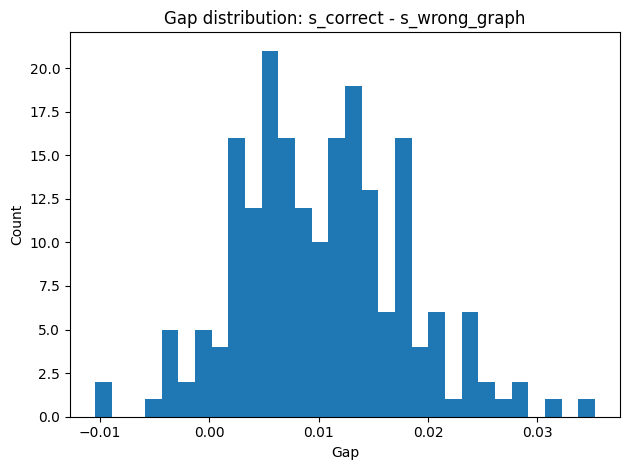

Gap mean: 0.010270207226276397
Gap std: 0.007622281480876218
Fraction with gap > 0: 0.94


In [16]:
#✅ Second check: distribution of the “gap”
#Even if wrong graph is close, the gap distribution matters.
import matplotlib.pyplot as plt

# Using df from the previous “proper check” you ran:
gap = df["s_correct"] - df["s_wrong_graph"]

plt.figure()
plt.hist(gap, bins=30)
plt.title("Gap distribution: s_correct - s_wrong_graph")
plt.xlabel("Gap")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Gap mean:", float(gap.mean()))
print("Gap std:", float(gap.std()))
print("Fraction with gap > 0:", float((gap > 0).mean()))


These results look good — they strongly suggest your Substep 3 matching is working and meaningful, even though the absolute cosine values are high.
Why it’s good
Top-1 retrieval accuracy = 0.54 (54% vs chance ~4%) ✅
Top-5 retrieval accuracy = 0.885 ✅
This means your video steps “retrieve” the correct recipe graph much more often than not. That’s a strong sign the embeddings are aligned in a recipe-specific way.
Gap stats (correct − wrong graph):
mean gap ≈ 0.0103
94% of videos have gap > 0 ✅
So even if the gap is small, it’s consistently positive.
Why wrong-graph similarity can still be high
Many cooking steps are semantically similar across recipes, and with your learned projection + normalized embeddings, cosine similarities can sit in a tight high range. What matters is ranking/retrieval, and you’re doing well there.
So what should you do now?
You can move to Substep 4.
But before that, there are two small improvements that will make your pipeline more correct and help Substep 4:
1) Add an “unmatched” option (don’t force every node to match)
Right now Hungarian always matches min(T, N) pairs, so every node gets a match if T >= N. For task verification, it’s useful to allow skipped steps.
Code: apply a similarity threshold after Hungarian
This will mark low-confidence matches as -1.

In [17]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def l2norm(x, eps=1e-8):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def hungarian_with_threshold(V, N, threshold=0.90):
    Vn = l2norm(V.astype(np.float32))
    Nn = l2norm(N.astype(np.float32))
    sim = Vn @ Nn.T
    r, c = linear_sum_assignment(-sim)

    T, K = sim.shape
    match_vis2node = np.full(T, -1, dtype=int)
    match_node2vis = np.full(K, -1, dtype=int)

    for i, j in zip(r, c):
        if sim[i, j] >= threshold:
            match_vis2node[i] = j
            match_node2vis[j] = i

    return match_vis2node, match_node2vis, sim


# step **4**

Cell 0 — Install deps (Colab)


In [18]:
# Colab: install PyTorch Geometric
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

import torch
print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())

# Install pyg + deps that match your torch/cuda
!pip -q install torch-geometric


torch: 2.9.0+cpu cuda: False
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.8 MB/s eta 0:00:00


Cell 1 — Paths + load labels + index matched graphs


In [19]:
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# EDIT PATHS IF NEEDED
# =========================
SUBSTEP3_DIR = "/content/drive/My Drive/AML_Project/substep3_matching"
MATCHED_DIR  = os.path.join(SUBSTEP3_DIR, "videos")  # contains *_matched.npz
LABELS_PATH  = "/content/drive/My Drive/AML_Project/task_verification_labels.csv"

matched_files = sorted(glob.glob(os.path.join(MATCHED_DIR, "*_matched.npz")))
if len(matched_files) == 0:
    raise RuntimeError(f"No *_matched.npz found in {MATCHED_DIR}")

labels_df = pd.read_csv(LABELS_PATH)
labels_df["video_id"] = labels_df["video_id"].astype(str)
labels_df["label"] = labels_df["label"].astype(int)
vid2label = dict(zip(labels_df["video_id"], labels_df["label"]))

rows = []
missing_labels = 0
for fp in matched_files:
    d = np.load(fp, allow_pickle=True)
    vid = str(d["video_id"])
    rid = str(d["recipe_id"])
    if vid not in vid2label:
        missing_labels += 1
        continue
    rows.append({"video_id": vid, "recipe_id": rid, "label": int(vid2label[vid]), "path": fp})

idx_df = pd.DataFrame(rows)
print("Matched files:", len(matched_files))
print("Usable (have label):", len(idx_df))
print("Missing label:", missing_labels)
print("Recipes:", idx_df["recipe_id"].nunique())
print("Label distribution:\n", idx_df["label"].value_counts())
display(idx_df.head())


Matched files: 384
Usable (have label): 384
Missing label: 0
Recipes: 24
Label distribution:
 label
0    220
1    164
Name: count, dtype: int64


,video_id,recipe_id,label,path
0,10_16_360p_224,10,1,/content/drive/My Drive/AML_Project/substep3_m...
1,10_18_360p_224,10,1,/content/drive/My Drive/AML_Project/substep3_m...
2,10_24_360p_224,10,1,/content/drive/My Drive/AML_Project/substep3_m...
3,10_26_360p_224,10,0,/content/drive/My Drive/AML_Project/substep3_m...
4,10_31_360p_224,10,0,/content/drive/My Drive/AML_Project/substep3_m...


Cell 2 — Build a PyG Dataset from your _matched.npz
Each file already contains:
edge_index (2,E)
node_text_emb (N,768)
node_vis_emb (N,768)
We keep text + vis separate so the model can apply learnable projections to each.

In [20]:
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data

class MatchedGraphDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        d = np.load(row["path"], allow_pickle=True)

        # node embeddings
        x_text = torch.tensor(d["node_text_emb"], dtype=torch.float32)  # [N,Dt]
        x_vis  = torch.tensor(d["node_vis_emb"],  dtype=torch.float32)  # [N,Dv]

        # edges
        edge_index = torch.tensor(d["edge_index"], dtype=torch.long)    # [2,E]

        y = torch.tensor([int(row["label"])], dtype=torch.float32)      # [1]
        recipe_id = str(row["recipe_id"])
        video_id = str(row["video_id"])

        data = Data(edge_index=edge_index, y=y)
        data.x_text = x_text
        data.x_vis = x_vis
        data.recipe_id = recipe_id
        data.video_id = video_id
        return data


Cell 3 — Model: Learnable fusion (text+vis) + GNN + graph pooling + binary head
This satisfies: “update the features of matched nodes with a learnable projection of node features and visual features”.

In [21]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv, global_mean_pool

class FusionGNN(nn.Module):
    def __init__(self, d_text=768, d_vis=768, d_hid=256, gnn_type="sage", num_layers=2, dropout=0.2):
        super().__init__()
        self.dropout = dropout

        # learnable projections (required by Substep 3 spec)
        self.Wt = nn.Linear(d_text, d_hid)
        self.Wv = nn.Linear(d_vis, d_hid)

        # fuse node features
        self.fuse = nn.Sequential(
            nn.ReLU(),
            nn.Linear(2*d_hid, d_hid),
            nn.ReLU()
        )

        # choose GNN layer
        convs = []
        for i in range(num_layers):
            in_ch = d_hid if i == 0 else d_hid
            if gnn_type == "gcn":
                convs.append(GCNConv(in_ch, d_hid))
            elif gnn_type == "gat":
                convs.append(GATv2Conv(in_ch, d_hid, heads=1, concat=False))
            else:  # default: GraphSAGE
                convs.append(SAGEConv(in_ch, d_hid))
        self.convs = nn.ModuleList(convs)

        # graph-level classifier
        self.cls = nn.Sequential(
            nn.Linear(d_hid, d_hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hid, 1)
        )

    def forward(self, data):
        # fuse node embeddings
        zt = self.Wt(data.x_text)
        zv = self.Wv(data.x_vis)
        x = self.fuse(torch.cat([zt, zv], dim=-1))  # [N, d_hid]

        # message passing (directed edges are fine; PyG respects direction)
        for conv in self.convs:
            x = conv(x, data.edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # pool nodes -> graph embedding
        g = global_mean_pool(x, data.batch)  # [B, d_hid]
        logits = self.cls(g).squeeze(-1)     # [B]
        return logits


Cell 4 — Train/Eval utilities + metrics


In [22]:
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import numpy as np
import random

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def compute_metrics(y_true, y_prob, thresh=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thresh).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = float("nan")
    return {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}

@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    ys, probs, vids = [], [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        prob = torch.sigmoid(logits).detach().cpu().numpy()
        y = batch.y.detach().cpu().numpy().reshape(-1)

        probs.extend(prob.tolist())
        ys.extend(y.tolist())
        vids.extend(batch.video_id)
    return ys, probs, vids

def train_one_fold(train_df, test_df, device, gnn_type="sage", epochs=40, batch_size=16, lr=3e-4, wd=1e-3):
    train_ds = MatchedGraphDataset(train_df)
    test_ds  = MatchedGraphDataset(test_df)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # class imbalance weight
    y_train = train_df["label"].values.astype(int)
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    pos_weight = torch.tensor((n_neg / max(n_pos,1)) if n_pos > 0 else 1.0, device=device)

    model = FusionGNN(gnn_type=gnn_type).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_state, best_f1 = None, -1.0

    for ep in range(1, epochs+1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(batch)
            loss = crit(logits, batch.y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # select best epoch by train F1 (no val split in LOO)
        tr_y, tr_p, _ = eval_model(model, train_loader, device)
        tr_m = compute_metrics(tr_y, tr_p)

        if tr_m["f1"] > best_f1:
            best_f1 = tr_m["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if ep in {1, 10, 20, 30, epochs}:
            print(f"  epoch {ep:02d} | train f1={tr_m['f1']:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    te_y, te_p, te_vids = eval_model(model, test_loader, device)
    te_m = compute_metrics(te_y, te_p)
    return te_m, te_y, te_p, te_vids


Cell 5 — Leave-one-recipe-out training + save results


In [23]:
set_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

recipes = sorted(idx_df["recipe_id"].unique().tolist(), key=lambda x: int(x))
print("LOO folds:", len(recipes))

fold_rows = []
pred_rows = []

GNN_TYPE = "sage"   # try: "gcn", "sage", "gat"

for rid in recipes:
    test_df = idx_df[idx_df["recipe_id"] == rid].copy()
    train_df = idx_df[idx_df["recipe_id"] != rid].copy()
    if len(test_df) == 0 or len(train_df) < 2:
        continue

    print(f"\n=== Hold out recipe {rid} | train={len(train_df)} test={len(test_df)} ===")
    m, y_true, y_prob, vids = train_one_fold(train_df, test_df, device, gnn_type=GNN_TYPE)

    fold_rows.append({"heldout_recipe": rid, "n_train": len(train_df), "n_test": len(test_df), **m})
    for vid, yt, yp in zip(vids, y_true, y_prob):
        pred_rows.append({"recipe_id": rid, "video_id": vid, "y_true": int(yt), "y_prob": float(yp)})

results_df = pd.DataFrame(fold_rows)
preds_df = pd.DataFrame(pred_rows)

print("\nPer-fold metrics:")
display(results_df)

print("\nMean across folds:")
display(results_df[["acc","precision","recall","f1","auc"]].mean(numeric_only=True))

# Save
OUT_METRICS = os.path.join(SUBSTEP3_DIR, f"substep4_gnn_{GNN_TYPE}_loo_metrics.csv")
OUT_PREDS   = os.path.join(SUBSTEP3_DIR, f"substep4_gnn_{GNN_TYPE}_loo_predictions.csv")
results_df.to_csv(OUT_METRICS, index=False)
preds_df.to_csv(OUT_PREDS, index=False)

print("\nSaved:")
print(" ", OUT_METRICS)
print(" ", OUT_PREDS)


Device: cpu
LOO folds: 24

=== Hold out recipe 1 | train=366 test=18 ===


/usr/local/lib/python3.12/dist-packages/torch_geometric/data/data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'x_text', 'y', 'x_vis', 'recipe_id', 'edge_index', 'video_id'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:142: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'x_text', 'y', 'x_vis', 'recipe_id', 'edge_index', 'video_id'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  repeats = [store.num_nodes or 0 for store in stores]


  epoch 01 | train f1=0.000


/usr/local/lib/python3.12/dist-packages/torch_geometric/data/data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'x_text', 'y', 'x_vis', 'recipe_id', 'edge_index', 'video_id'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:142: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'x_text', 'y', 'x_vis', 'recipe_id', 'edge_index', 'video_id'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  repeats = [store.num_nodes or 0 for store in stores]
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'x_text', 'y', 'x_vis', 'recipe_id', 'edge_index', 'video_id'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppres

  epoch 10 | train f1=0.562


...

/usr/local/lib/python3.12/dist-packages/torch_geometric/data/data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'x_text', 'y', 'x_vis', 'recipe_id', 'edge_index', 'video_id'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:142: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'x_text', 'y', 'x_vis', 'recipe_id', 'edge_index', 'video_id'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  repeats = [store.num_nodes or 0 for store in stores]


,heldout_recipe,n_train,n_test,acc,precision,recall,f1,auc
0,1,366,18,0.833333,0.666667,0.800000,0.727273,0.769231
1,2,368,16,0.812500,0.714286,0.833333,0.769231,0.833333
2,3,371,13,0.769231,1.000000,0.400000,0.571429,0.625000
3,4,367,17,0.647059,0.833333,0.500000,0.625000,0.728571
4,5,369,15,0.666667,0.800000,0.500000,0.615385,0.714286
5,7,368,16,0.687500,0.600000,0.500000,0.545455,0.600000
6,8,368,16,0.687500,1.000000,0.166667,0.285714,0.766667
7,9,370,14,0.500000,0.750000,0.333333,0.461538,0.511111
8,10,372,12,0.333333,0.300000,0.750000,0.428571,0.593750
9,12,366,18,0.555556,0.666667,0.545455,0.600000,0.636364



Mean across folds:


,0
acc,0.634889
precision,0.604845
recall,0.492172
f1,0.508575
auc,0.640769



Saved:
  /content/drive/My Drive/AML_Project/substep3_matching/substep4_gnn_sage_loo_metrics.csv
  /content/drive/My Drive/AML_Project/substep3_matching/substep4_gnn_sage_loo_predictions.csv
